# Benchmark model performance

This notebooks benchmarks the available predictive models on sequence data.

In [1]:
import collections
import itertools
import os

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from Bio.SeqUtils import IUPACData
from nettcr.models import NetTCR
from scipy import stats
from sklearn import metrics

from tcr_antigen_prediction.models import TCRStructMap

In [2]:
with h5py.File('data/processed/sequences.h5') as fh:
    cdr1_alphas = fh['cdr1_alpha'][:]
    cdr2_alphas = fh['cdr2_alpha'][:]
    cdr3_alphas = fh['cdr3_alpha'][:]
    cdr1_betas = fh['cdr1_beta'][:]
    cdr2_betas = fh['cdr2_beta'][:]
    cdr3_betas = fh['cdr3_beta'][:]
    peptides = fh['peptide'][:]
    mhcs = fh['mhc_pseudo'][:]

    folds = fh['fold'][:]
    labels = fh['label'][:]

In [3]:
predictions = []

for fold_num in range(1, 5 + 1):
    print('Fold:', fold_num)
    hold_out_indicies = np.where(folds == fold_num)[0]

    for model_path in 'models/TCRStructMap', 'models/TCRStructMap_sequence_only':
        print('Loading model:', model_path)
        model = TCRStructMap()
        model.load_state_dict(
            torch.load(
                os.path.join(model_path, f'model_{fold_num}.pt'),
                map_location=torch.device('cpu'),
                weights_only=True,
            )
        )

        print('Making predictions')
        model.eval()

        prediction = model(
            torch.tensor(cdr1_alphas[hold_out_indicies], dtype=torch.float32),
            torch.tensor(cdr2_alphas[hold_out_indicies], dtype=torch.float32),
            torch.tensor(cdr3_alphas[hold_out_indicies], dtype=torch.float32),
            torch.tensor(cdr1_betas[hold_out_indicies], dtype=torch.float32),
            torch.tensor(cdr2_betas[hold_out_indicies], dtype=torch.float32),
            torch.tensor(cdr3_betas[hold_out_indicies], dtype=torch.float32),
            torch.tensor(peptides[hold_out_indicies], dtype=torch.float32),
            torch.tensor(mhcs[hold_out_indicies], dtype=torch.float32),
        )

        model_name = os.path.basename(model_path)

        predictions.append(
            pd.DataFrame(
                {
                    'index': hold_out_indicies,
                    'fold': [fold_num for _ in range(len(hold_out_indicies))],
                    'model_name': [model_name for _ in range(len(hold_out_indicies))],
                    'label': labels[hold_out_indicies],
                    'prediction': prediction.squeeze(-1).detach().cpu().numpy(),
                }
            )
        )

predictions = pd.concat(predictions)

Fold: 1
Loading model: models/TCRStructMap
Making predictions
Loading model: models/TCRStructMap_sequence_only
Making predictions
Fold: 2
Loading model: models/TCRStructMap
Making predictions
Loading model: models/TCRStructMap_sequence_only
Making predictions
Fold: 3
Loading model: models/TCRStructMap
Making predictions
Loading model: models/TCRStructMap_sequence_only
Making predictions
Fold: 4
Loading model: models/TCRStructMap
Making predictions
Loading model: models/TCRStructMap_sequence_only
Making predictions
Fold: 5
Loading model: models/TCRStructMap
Making predictions
Loading model: models/TCRStructMap_sequence_only
Making predictions


In [4]:
with h5py.File('data/processed/sequences_right_pad_blosum.h5') as fh:
    cdr1_alphas_nettcr = fh['cdr1_alpha'][:]
    cdr2_alphas_nettcr = fh['cdr2_alpha'][:]
    cdr3_alphas_nettcr = fh['cdr3_alpha'][:]
    cdr1_betas_nettcr = fh['cdr1_beta'][:]
    cdr2_betas_nettcr = fh['cdr2_beta'][:]
    cdr3_betas_nettcr = fh['cdr3_beta'][:]
    peptides_nettcr = fh['peptide'][:]

    folds_nettcr = fh['fold'][:]
    labels_nettcr = fh['label'][:]

In [5]:
predictions_nettcr = []

for fold_num in range(1, 5 + 1):
    print('Fold:', fold_num)
    hold_out_indicies = np.where(folds_nettcr == fold_num)[0]

    model = NetTCR()
    model.load_state_dict(
        torch.load(
            os.path.join('models/NetTCR', f'model_{fold_num}.pt'),
            map_location=torch.device('cpu'),
            weights_only=True,
        )
    )

    print('Making predictions')
    model.eval()

    prediction = model(
        torch.tensor(cdr1_alphas_nettcr[hold_out_indicies], dtype=torch.float32),
        torch.tensor(cdr2_alphas_nettcr[hold_out_indicies], dtype=torch.float32),
        torch.tensor(cdr3_alphas_nettcr[hold_out_indicies], dtype=torch.float32),
        torch.tensor(cdr1_betas_nettcr[hold_out_indicies], dtype=torch.float32),
        torch.tensor(cdr2_betas_nettcr[hold_out_indicies], dtype=torch.float32),
        torch.tensor(cdr3_betas_nettcr[hold_out_indicies], dtype=torch.float32),
        torch.tensor(peptides_nettcr[hold_out_indicies], dtype=torch.float32),
    )

    predictions_nettcr.append(
        pd.DataFrame(
            {
                'index': hold_out_indicies,
                'fold': [fold_num for _ in range(len(hold_out_indicies))],
                'model_name': ['NetTCR' for _ in range(len(hold_out_indicies))],
                'label': labels_nettcr[hold_out_indicies],
                'prediction': prediction.squeeze(-1).detach().cpu().numpy(),
            }
        )
    )

predictions_nettcr = pd.concat(predictions_nettcr)

Fold: 1
Making predictions
Fold: 2
Making predictions
Fold: 3
Making predictions
Fold: 4
Making predictions
Fold: 5
Making predictions


In [6]:
predictions = pd.concat([predictions, predictions_nettcr])

In [7]:
def model_name_sort_key(name: str) -> tuple[str, str]:
    return (-ord(name[0]), name)

In [8]:
amino_acid_olcs = np.array(sorted(IUPACData.protein_letters_3to1.values()))
amino_acid_olcs

array(['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P',
       'Q', 'R', 'S', 'T', 'V', 'W', 'Y'], dtype='<U1')

In [9]:
peptides_aa = np.array(
    [
        ''.join([amino_acid_olcs[one_hot.astype(bool)][0] for one_hot in peptide if np.sum(one_hot) > 0])
        for peptide in peptides
    ]
)

In [10]:
predictions['peptide'] = predictions['index'].map(lambda idx: peptides_aa[idx])

In [11]:
with open('data/interim/peptides.txt') as fh:
    peptide_key = np.array(fh.read().rstrip().split('\n'))

peptide_distances = np.loadtxt('data/interim/peptide_distances.txt', dtype=int)

In [12]:
# TODO think about how to handle peptides that have been cropped...


def get_minimum_peptide_distance(peptide: str, training_peptides: np.ndarray) -> int:
    if peptide not in peptide_key:
        return np.nan

    training_key_idxs = np.where(np.isin(peptide_key, training_peptides))[0]
    peptide_index = np.where(peptide == peptide_key)[0][0]

    return np.min(peptide_distances[peptide_index][training_key_idxs])

In [13]:
peptide_folds = predictions[['peptide', 'fold', 'model_name']].drop_duplicates()
peptide_folds['min_peptide_distance'] = peptide_folds.apply(
    lambda row: get_minimum_peptide_distance(
        row.peptide,
        peptides_aa[folds_nettcr != row.fold] if row.model_name == 'NetTCR' else peptides_aa[folds != row.fold],
    ),
    axis=1,
)

In [14]:
predictions = predictions.merge(peptide_folds, how='left', on=['peptide', 'fold', 'model_name'])

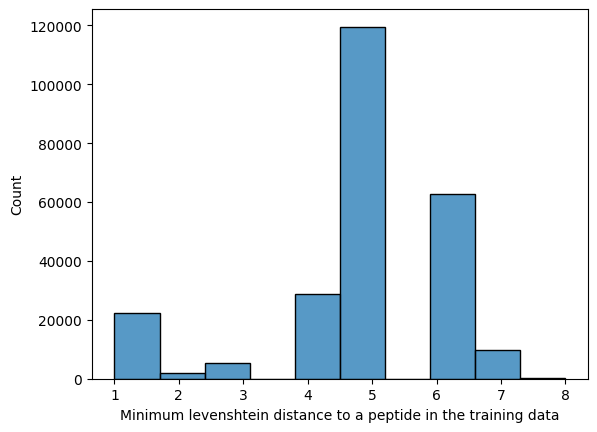

In [15]:
sns.histplot(predictions, x='min_peptide_distance', bins=10)

plt.xlabel('Minimum levenshtein distance to a peptide in the training data')
plt.show()

## Model Size

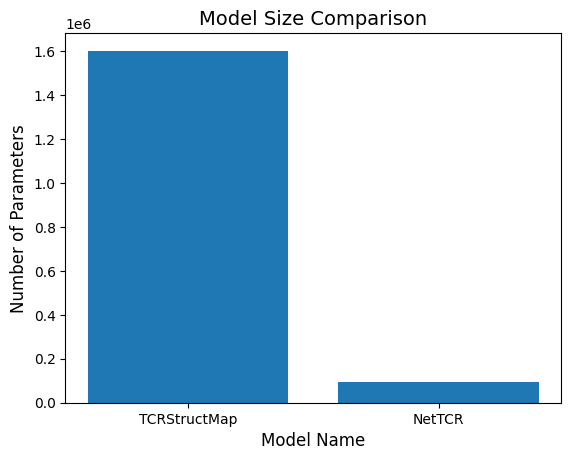

In [16]:
def count_parameters(model: torch.nn.Module) -> int:
    """Count the number of parmeters in a pytorch model."""
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


plt.bar(x=['TCRStructMap', 'NetTCR'], height=[count_parameters(model) for model in (TCRStructMap(), NetTCR())])

plt.title('Model Size Comparison', fontsize=14)
plt.xlabel('Model Name', fontsize=12)
plt.ylabel('Number of Parameters', fontsize=12)

plt.show()

## ROC

In [17]:
roc_results = predictions.groupby(['model_name']).apply(
    lambda group: metrics.roc_curve(group['label'], group['prediction']),
    include_groups=False,
)
roc_results.name = 'roc_curve'
roc_results = roc_results.reset_index()

In [18]:
roc_results[['fpr', 'tpr', 'threshold']] = roc_results['roc_curve'].apply(pd.Series)
roc_results['roc_auc'] = roc_results.apply(lambda row: metrics.auc(row['fpr'], row['tpr']), axis=1)

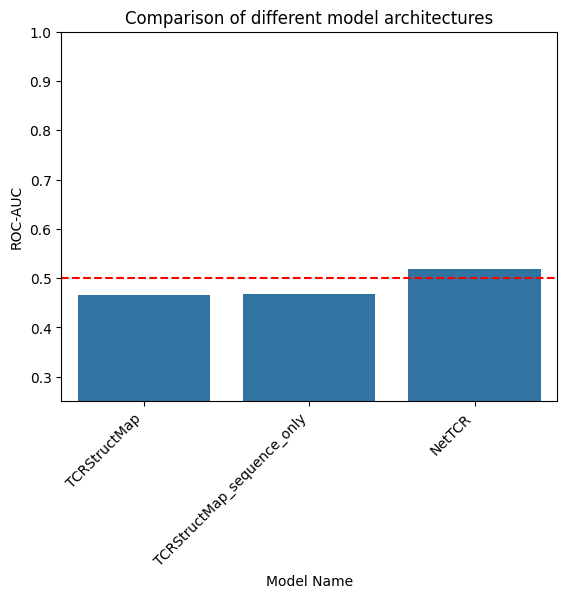

In [19]:
plt.title('Comparison of different model architectures')

sns.barplot(
    roc_results, x='model_name', y='roc_auc', order=sorted(roc_results['model_name'].unique(), key=model_name_sort_key)
)

plt.axhline(0.5, color='r', linestyle='dashed')

plt.ylabel('ROC-AUC')
plt.xlabel('Model Name')
plt.xticks(rotation=45, ha='right')
plt.ylim([0.25, 1.0])
plt.show()

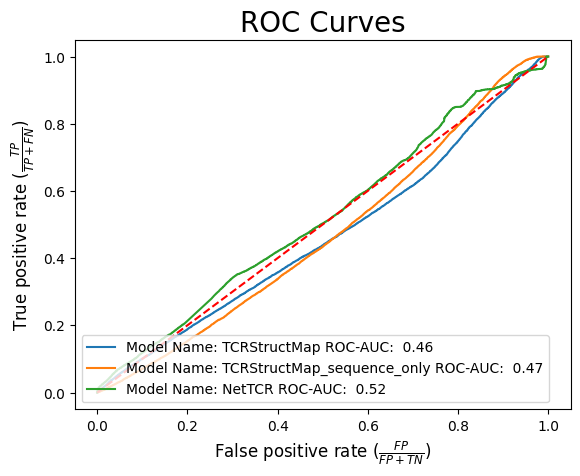

In [ ]:
model_groups = roc_results.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=lambda name: (-ord(name[0]), name, len(name)))

plt.title('ROC Curves', fontsize=20)

for model_name in model_group_names:
    model_group = model_groups.get_group(model_name)

    roc_auc = model_group['roc_auc'].to_numpy()[0]
    group = model_group.explode(['tpr', 'fpr'])

    plt.plot(group['fpr'], group['tpr'], label=f'Model Name: {model_name} ROC-AUC: {roc_auc: .2f}')

plt.ylabel(r'True positive rate ($\frac{TP}{TP + FN}$)', fontsize=12)
plt.xlabel(r'False positive rate ($\frac{FP}{FP + TN}$)', fontsize=12)

plt.plot([0, 1], [0, 1], 'r--')
plt.legend()

plt.show()

### Comparison of prediction results to mimimum distance between the peptides and the training set

In [21]:
roc_results_by_peptide_distance = predictions.groupby(['model_name', 'min_peptide_distance']).apply(
    lambda group: metrics.roc_auc_score(group['label'], group['prediction']),
    include_groups=False,
)
roc_results_by_peptide_distance.name = 'roc_auc'

roc_results_by_peptide_distance = roc_results_by_peptide_distance.reset_index()

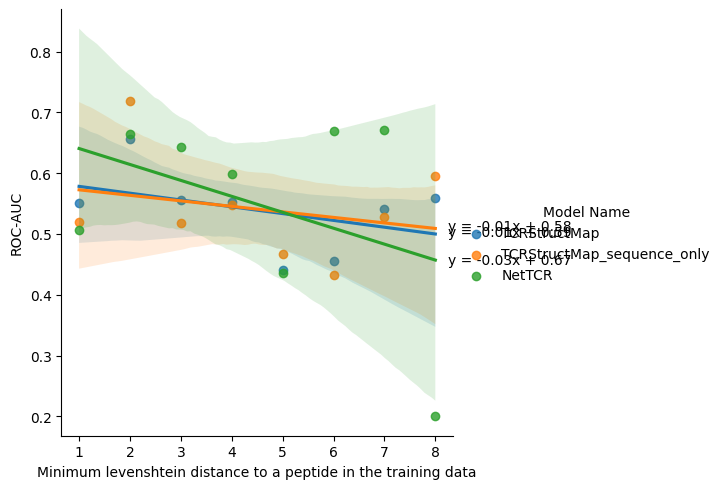

In [22]:
ax = sns.lmplot(
    roc_results_by_peptide_distance,
    x='min_peptide_distance',
    y='roc_auc',
    hue='model_name',
    hue_order=sorted(roc_results_by_peptide_distance['model_name'].unique(), key=model_name_sort_key),
)

for model_name in roc_results_by_peptide_distance['model_name'].unique():
    subset = roc_results_by_peptide_distance[roc_results_by_peptide_distance['model_name'] == model_name]
    slope, intercept, r_value, p_value, std_err = stats.linregress(subset['min_peptide_distance'], subset['roc_auc'])

    equation = f'y = {slope:.2f}x + {intercept:.2f}'

    x_pos = subset['min_peptide_distance'].max() + 0.25
    y_pos = slope * x_pos + intercept

    plt.text(x_pos, y_pos, equation, color='black')

ax.legend.set_title('Model Name')
plt.xlabel('Minimum levenshtein distance to a peptide in the training data')
plt.ylabel('ROC-AUC')

plt.show()

### Grouping ROC-AUC by Fold

In [23]:
roc_results_by_fold = predictions.groupby(['model_name', 'fold']).apply(
    lambda group: metrics.roc_curve(group['label'], group['prediction']),
    include_groups=False,
)
roc_results_by_fold.name = 'roc_curve'
roc_results_by_fold = roc_results_by_fold.reset_index()

In [24]:
roc_results_by_fold[['fpr', 'tpr', 'threshold']] = roc_results_by_fold['roc_curve'].apply(pd.Series)

In [25]:
roc_results_by_fold['roc_auc'] = roc_results_by_fold.apply(lambda row: metrics.auc(row['fpr'], row['tpr']), axis=1)

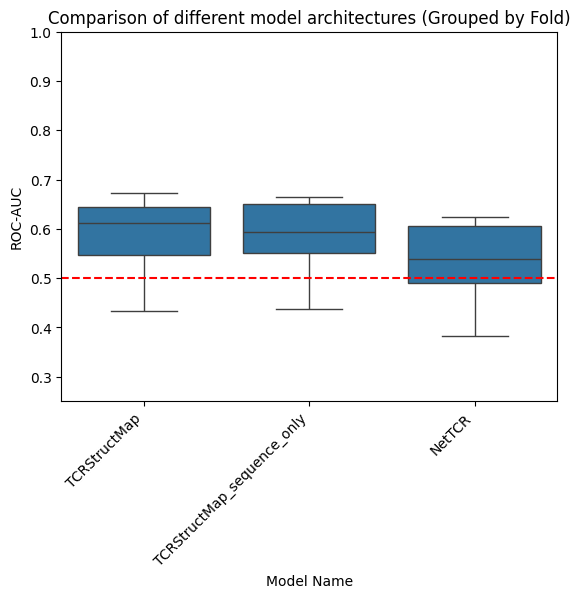

,mean,median,std
model_name,,,
TCRStructMap,0.582022,0.612001,0.095338
TCRStructMap_sequence_only,0.579386,0.593776,0.091755
NetTCR,0.528512,0.539377,0.097343


In [26]:
plt.title('Comparison of different model architectures (Grouped by Fold)')

sns.boxplot(
    roc_results_by_fold,
    x='model_name',
    y='roc_auc',
    order=sorted(roc_results_by_fold['model_name'].unique(), key=model_name_sort_key),
)
plt.axhline(0.5, color='r', linestyle='dashed')

plt.ylabel('ROC-AUC')
plt.xlabel('Model Name')
plt.xticks(rotation=45, ha='right')
plt.ylim([0.25, 1.0])
plt.show()

roc_results_by_fold_agg = roc_results_by_fold.groupby('model_name')['roc_auc'].agg(['mean', 'median', 'std'])
roc_results_by_fold_agg = roc_results_by_fold_agg.loc[sorted(roc_results_by_fold_agg.index, key=model_name_sort_key)]

roc_results_by_fold_agg

In [27]:
groups = list(roc_results_by_fold.groupby('model_name')['roc_auc'])
groups = sorted(groups, key=lambda group: model_name_sort_key(group[0]))

print(stats.kruskal(*[group for _, group in groups]))

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.ranksums(group1, group2)

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

KruskalResult(statistic=np.float64(1.5), pvalue=np.float64(0.4723665527410149))


,group1,group2,stat,p_val,signficant
0,TCRStructMap,TCRStructMap_sequence_only,-0.104447,0.916815,False
1,TCRStructMap,NetTCR,1.148913,0.250592,False
2,TCRStructMap_sequence_only,NetTCR,0.940019,0.347208,False


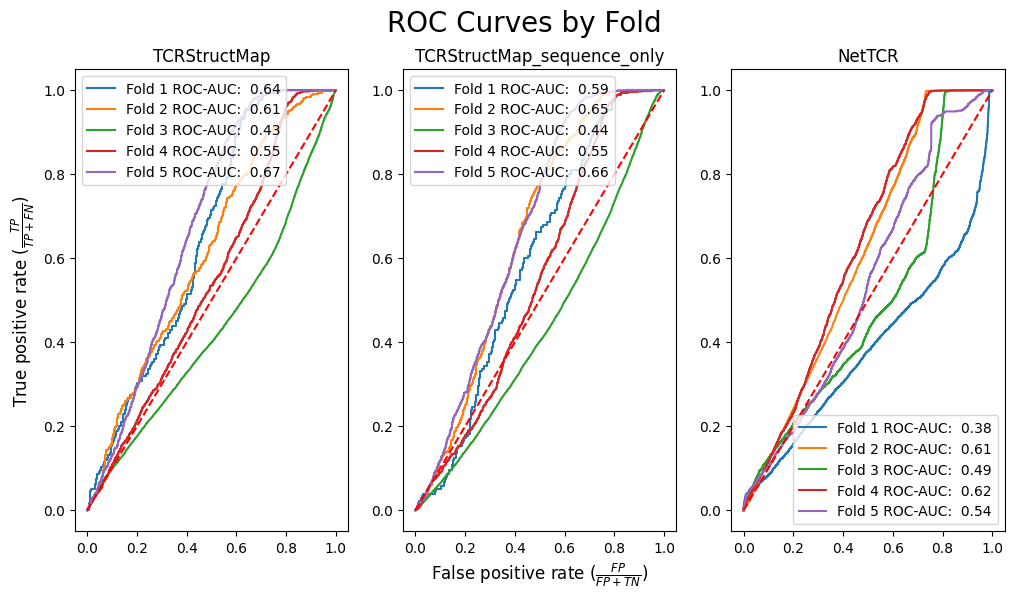

In [28]:
model_groups = roc_results_by_fold.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=lambda name: (-ord(name[0]), name, len(name)))

fig, axes = plt.subplots(1, len(model_groups), figsize=(12, 6))

fig.suptitle('ROC Curves by Fold', fontsize=20)

for i, model_name in enumerate(model_group_names):
    model_group = model_groups.get_group(model_name)

    for fold, fold_group in model_group.groupby('fold'):
        roc_auc = fold_group['roc_auc'].to_numpy()[0]
        group = fold_group.explode(['tpr', 'fpr'])

        axes[i].plot(group['fpr'], group['tpr'], label=f'Fold {fold} ROC-AUC: {roc_auc: .2f}')

    if i == 0:
        axes[i].set_ylabel(r'True positive rate ($\frac{TP}{TP + FN}$)', fontsize=12)

    if i == len(model_groups) // 2:
        axes[i].set_xlabel(r'False positive rate ($\frac{FP}{FP + TN}$)', fontsize=12)

    axes[i].set_title(model_name)

    axes[i].plot([0, 1], [0, 1], 'r--')
    axes[i].legend()

In [29]:
model_groups = roc_results_by_fold.groupby('model_name')

fpr_interp = np.linspace(0, 1, 100)
tpr_interp = {}

for model_name, model_group in model_groups:
    tpr_interp[model_name] = {}
    for fold, fold_group in model_group.groupby('fold'):
        group = fold_group.explode(['tpr', 'fpr'])

        tpr_interp[model_name][fold] = np.interp(fpr_interp, group['fpr'].apply(float), group['tpr'].apply(float))

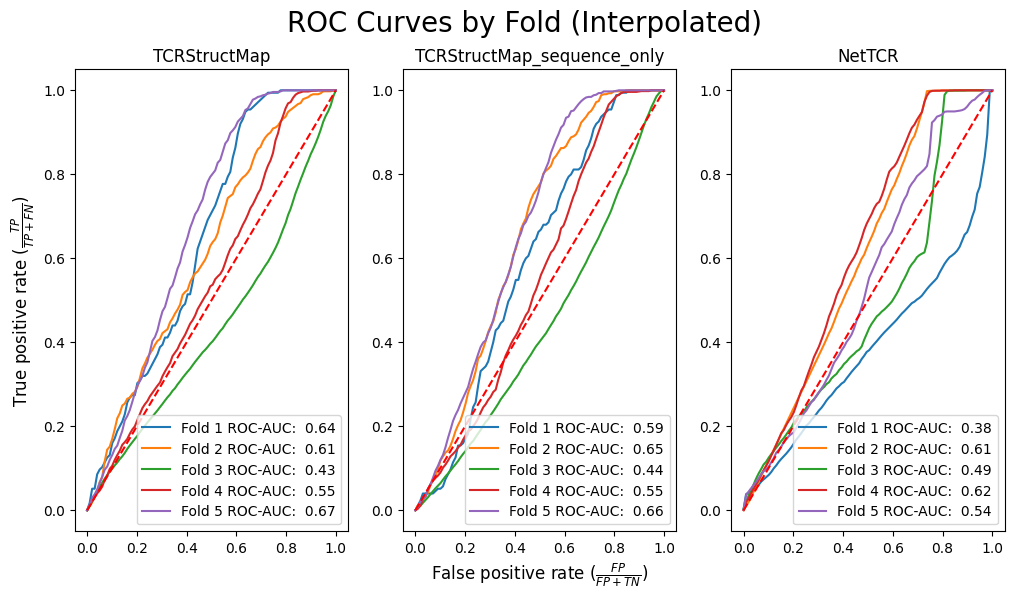

In [30]:
model_groups = roc_results_by_fold.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=model_name_sort_key)

fig, axes = plt.subplots(1, len(model_groups), figsize=(12, 6))

fig.suptitle('ROC Curves by Fold (Interpolated)', fontsize=20)

for i, model_name in enumerate(model_group_names):
    model_group = model_groups.get_group(model_name)

    for fold, fold_group in model_group.groupby('fold'):
        roc_auc = fold_group['roc_auc'].to_numpy()[0]

        axes[i].plot(fpr_interp, tpr_interp[model_name][fold], label=f'Fold {fold} ROC-AUC: {roc_auc: .2f}')

    if i == 0:
        axes[i].set_ylabel(r'True positive rate ($\frac{TP}{TP + FN}$)', fontsize=12)

    if i == len(model_groups) // 2:
        axes[i].set_xlabel(r'False positive rate ($\frac{FP}{FP + TN}$)', fontsize=12)

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [0, 1], 'r--')
    axes[i].legend()

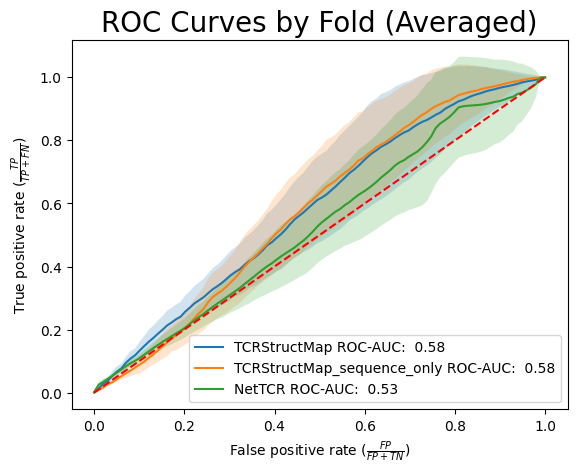

In [31]:
model_groups = roc_results_by_fold.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=model_name_sort_key)

for model_name in model_group_names:
    model_group = model_groups.get_group(model_name)

    tpr_mean = np.mean(np.array(list(tpr_interp[model_name].values())).T, axis=1)
    tpr_std = np.std(np.array(list(tpr_interp[model_name].values())).T, axis=1)

    roc_auc = metrics.auc(fpr_interp, tpr_mean)

    plt.plot(fpr_interp, tpr_mean, label=f'{model_name} ROC-AUC: {roc_auc: .2f}')
    plt.fill_between(fpr_interp, tpr_mean - tpr_std, tpr_mean + tpr_std, alpha=0.2)

plt.title('ROC Curves by Fold (Averaged)', fontsize=20)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel(r'False positive rate ($\frac{FP}{FP + TN}$)')
plt.ylabel(r'True positive rate ($\frac{TP}{TP + FN}$)')
plt.legend()

plt.show()

#### Comparison of prediction results to mimimum distance between the peptides and the training set

In [32]:
roc_results_by_fold_by_peptide_distance = predictions.groupby(['model_name', 'fold', 'min_peptide_distance']).apply(
    lambda group: metrics.roc_auc_score(group['label'], group['prediction']),
    include_groups=False,
)
roc_results_by_fold_by_peptide_distance.name = 'roc_auc'

roc_results_by_fold_by_peptide_distance = roc_results_by_fold_by_peptide_distance.reset_index()

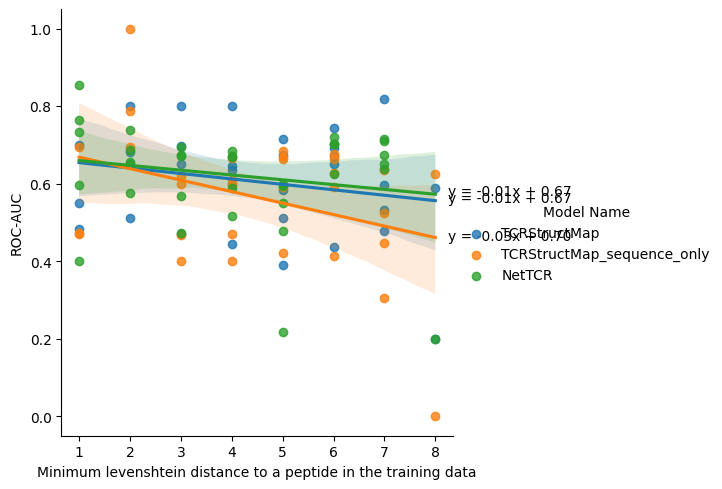

In [33]:
ax = sns.lmplot(
    roc_results_by_fold_by_peptide_distance,
    x='min_peptide_distance',
    y='roc_auc',
    hue='model_name',
    hue_order=sorted(roc_results_by_fold_by_peptide_distance['model_name'].unique(), key=model_name_sort_key),
)

for model_name in roc_results_by_fold_by_peptide_distance['model_name'].unique():
    subset = roc_results_by_fold_by_peptide_distance[
        roc_results_by_fold_by_peptide_distance['model_name'] == model_name
    ]
    slope, intercept, r_value, p_value, std_err = stats.linregress(subset['min_peptide_distance'], subset['roc_auc'])

    equation = f'y = {slope:.2f}x + {intercept:.2f}'

    x_pos = subset['min_peptide_distance'].max() + 0.25
    y_pos = slope * x_pos + intercept

    plt.text(x_pos, y_pos, equation, color='black')

ax.legend.set_title('Model Name')
plt.xlabel('Minimum levenshtein distance to a peptide in the training data')
plt.ylabel('ROC-AUC')

plt.show()

In [34]:
fold_peptide_distance_roc_aucs_lines = roc_results_by_fold_by_peptide_distance.groupby(['model_name', 'fold']).apply(
    lambda group: stats.linregress(group['min_peptide_distance'], group['roc_auc']),
    include_groups=False,
)

fold_peptide_distance_roc_aucs_lines.name = 'line'
fold_peptide_distance_roc_aucs_lines = fold_peptide_distance_roc_aucs_lines.reset_index()

fold_peptide_distance_roc_aucs_lines[['slope', 'intercept', 'r_value', 'p_value', 'std_err']] = (
    fold_peptide_distance_roc_aucs_lines['line'].apply(pd.Series)
)

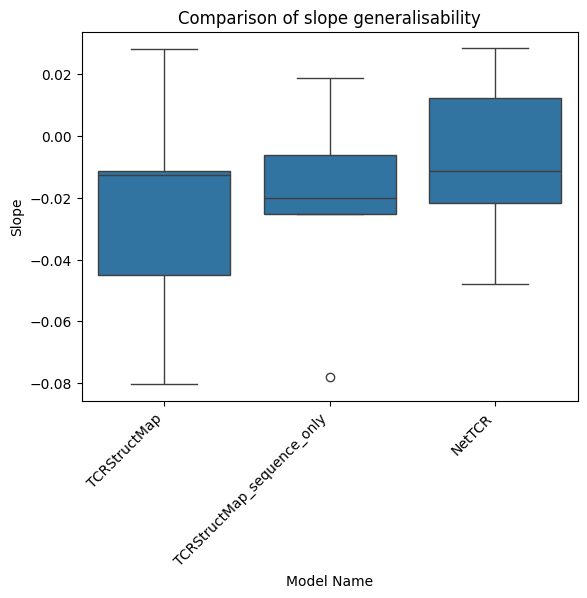

,mean,median,std
model_name,,,
TCRStructMap,-0.024220,-0.012713,0.040748
TCRStructMap_sequence_only,-0.022096,-0.019969,0.035655
NetTCR,-0.007999,-0.011204,0.029697


In [35]:
sns.boxplot(
    fold_peptide_distance_roc_aucs_lines,
    x='model_name',
    y='slope',
    order=sorted(fold_peptide_distance_roc_aucs_lines['model_name'].unique(), key=model_name_sort_key),
)

plt.title('Comparison of slope generalisability')
plt.ylabel('Slope')
plt.xlabel('Model Name')
plt.xticks(rotation=45, ha='right')
plt.show()

fold_peptide_distance_roc_aucs_lines_agg = fold_peptide_distance_roc_aucs_lines.groupby('model_name')['slope'].agg(
    ['mean', 'median', 'std'],
)
fold_peptide_distance_roc_aucs_lines_agg = fold_peptide_distance_roc_aucs_lines_agg.loc[
    sorted(fold_peptide_distance_roc_aucs_lines_agg.index, key=model_name_sort_key)
]
fold_peptide_distance_roc_aucs_lines_agg

In [36]:
groups = list(fold_peptide_distance_roc_aucs_lines.groupby('model_name')['slope'])

print(stats.kruskal(*[group for _, group in groups]))

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.ranksums(group1, group2)

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

KruskalResult(statistic=np.float64(0.5600000000000023), pvalue=np.float64(0.7557837414557247))


,group1,group2,stat,p_val,signficant
0,NetTCR,TCRStructMap,0.731126,0.464702,False
1,NetTCR,TCRStructMap_sequence_only,0.522233,0.601508,False
2,TCRStructMap,TCRStructMap_sequence_only,-0.104447,0.916815,False


Removing outlier to see the effect...

In [37]:
roc_results_by_fold_by_peptide_distance.sort_values('roc_auc')

,model_name,fold,min_peptide_distance,roc_auc
76,TCRStructMap_sequence_only,2,8.0,0.000000
45,TCRStructMap,2,8.0,0.200000
35,NetTCR,5,8.0,0.200000
4,NetTCR,1,5.0,0.218585
70,TCRStructMap_sequence_only,1,7.0,0.303906
...,...,...,...,...
63,TCRStructMap,5,3.0,0.800000
47,TCRStructMap,3,2.0,0.800000
44,TCRStructMap,2,7.0,0.818750
21,NetTCR,4,1.0,0.853500


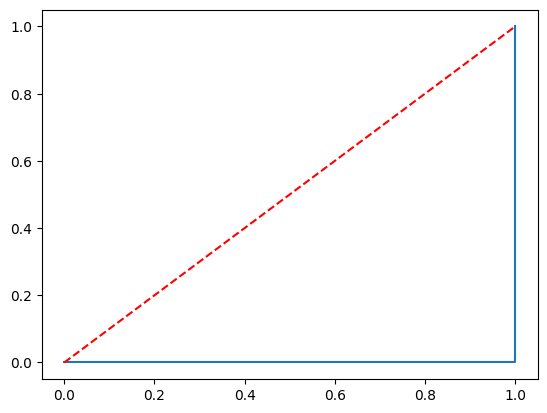

In [38]:
worst_fold = predictions.query(
    "model_name == 'TCRStructMap_sequence_only' and fold == 2 and min_peptide_distance == 8.0"
)
fpr, tpr, thresholds = metrics.roc_curve(worst_fold['label'], worst_fold['prediction'])

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], 'r--')

plt.show()

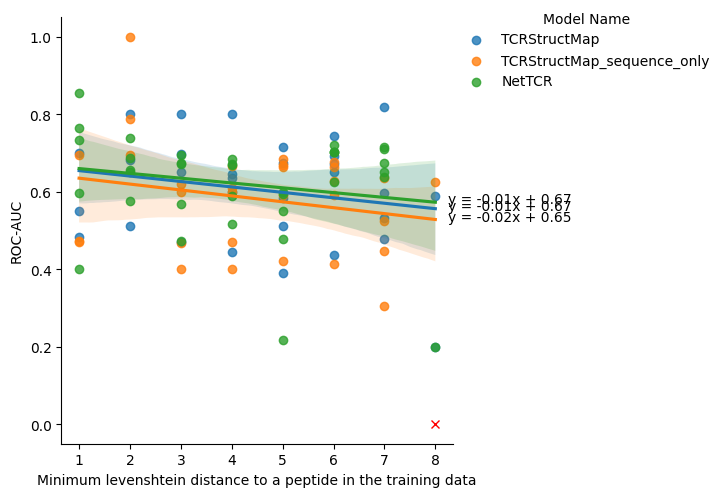

In [39]:
peptide_distance_roc_aucs_remove_outlier = roc_results_by_fold_by_peptide_distance.query(
    "not (model_name == 'TCRStructMap_sequence_only' and fold == 2 and min_peptide_distance == 8.0)"
)

peptide_distance_roc_aucs_outlier = roc_results_by_fold_by_peptide_distance.query(
    "model_name == 'TCRStructMap_sequence_only' and fold == 2 and min_peptide_distance == 8.0"
)

ax = sns.lmplot(
    peptide_distance_roc_aucs_remove_outlier,
    x='min_peptide_distance',
    y='roc_auc',
    hue='model_name',
    hue_order=sorted(peptide_distance_roc_aucs_remove_outlier['model_name'].unique(), key=model_name_sort_key),
)

for model_name in peptide_distance_roc_aucs_remove_outlier['model_name'].unique():
    subset = peptide_distance_roc_aucs_remove_outlier[
        peptide_distance_roc_aucs_remove_outlier['model_name'] == model_name
    ]
    slope, intercept, r_value, p_value, std_err = stats.linregress(subset['min_peptide_distance'], subset['roc_auc'])

    equation = f'y = {slope:.2f}x + {intercept:.2f}'

    x_pos = subset['min_peptide_distance'].max() + 0.25
    y_pos = slope * x_pos + intercept

    plt.text(x_pos, y_pos, equation, color='black')

plt.plot(peptide_distance_roc_aucs_outlier['min_peptide_distance'], peptide_distance_roc_aucs_outlier['roc_auc'], 'rx')

ax.legend.set_title('Model Name')
sns.move_legend(ax, 'upper right')
plt.xlabel('Minimum levenshtein distance to a peptide in the training data')
plt.ylabel('ROC-AUC')

plt.show()

In [40]:
peptide_distance_roc_aucs_remove_outlier_lines = peptide_distance_roc_aucs_remove_outlier.groupby(
    ['model_name', 'fold'],
).apply(
    lambda group: stats.linregress(group['min_peptide_distance'], group['roc_auc']),
    include_groups=False,
)

peptide_distance_roc_aucs_remove_outlier_lines.name = 'line'
peptide_distance_roc_aucs_remove_outlier_lines = peptide_distance_roc_aucs_remove_outlier_lines.reset_index()

peptide_distance_roc_aucs_remove_outlier_lines[['slope', 'intercept', 'r_value', 'p_value', 'std_err']] = (
    peptide_distance_roc_aucs_remove_outlier_lines['line'].apply(pd.Series)
)

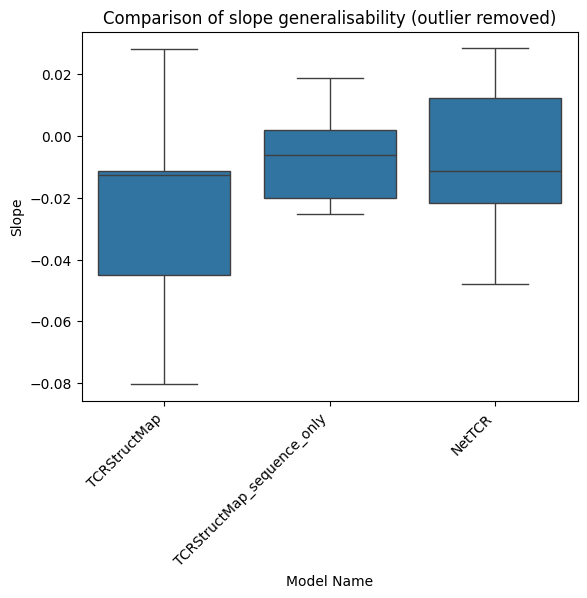

,mean,median,std
model_name,,,
TCRStructMap,-0.024220,-0.012713,0.040748
TCRStructMap_sequence_only,-0.006073,-0.006165,0.017658
NetTCR,-0.007999,-0.011204,0.029697


In [41]:
sns.boxplot(
    peptide_distance_roc_aucs_remove_outlier_lines,
    x='model_name',
    y='slope',
    order=sorted(peptide_distance_roc_aucs_remove_outlier_lines['model_name'].unique(), key=model_name_sort_key),
)

plt.title('Comparison of slope generalisability (outlier removed)')
plt.xlabel('Model Name')
plt.ylabel('Slope')
plt.xticks(rotation=45, ha='right')
plt.show()

peptide_distance_roc_aucs_remove_outlier_lines_agg = peptide_distance_roc_aucs_remove_outlier_lines.groupby(
    'model_name'
)['slope'].agg(['mean', 'median', 'std'])
peptide_distance_roc_aucs_remove_outlier_lines_agg = peptide_distance_roc_aucs_remove_outlier_lines_agg.loc[
    sorted(peptide_distance_roc_aucs_remove_outlier_lines_agg.index, key=model_name_sort_key)
]
peptide_distance_roc_aucs_remove_outlier_lines_agg

In [42]:
groups = list(peptide_distance_roc_aucs_remove_outlier_lines.groupby('model_name')['slope'])
groups = sorted(groups, key=lambda group: model_name_sort_key(group[0]))

print(stats.kruskal(*[group for _, group in groups]))

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.ranksums(group1, group2)

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

KruskalResult(statistic=np.float64(0.740000000000002), pvalue=np.float64(0.6907343306373539))


,group1,group2,stat,p_val,signficant
0,TCRStructMap,TCRStructMap_sequence_only,-0.731126,0.464702,False
1,TCRStructMap,NetTCR,-0.731126,0.464702,False
2,TCRStructMap_sequence_only,NetTCR,0.104447,0.916815,False


### Grouping ROC-AUC by Peptide

In [43]:
roc_results_by_peptide = predictions.groupby(['model_name', 'peptide']).apply(
    lambda group: metrics.roc_curve(group['label'], group['prediction']),
    include_groups=False,
)
roc_results_by_peptide.name = 'roc_curve'
roc_results_by_peptide = roc_results_by_peptide.reset_index()

In [44]:
roc_results_by_peptide[['fpr', 'tpr', 'threshold']] = roc_results_by_peptide['roc_curve'].apply(pd.Series)

In [45]:
roc_results_by_peptide['roc_auc'] = roc_results_by_peptide.apply(
    lambda row: metrics.auc(row['fpr'], row['tpr']), axis=1
)

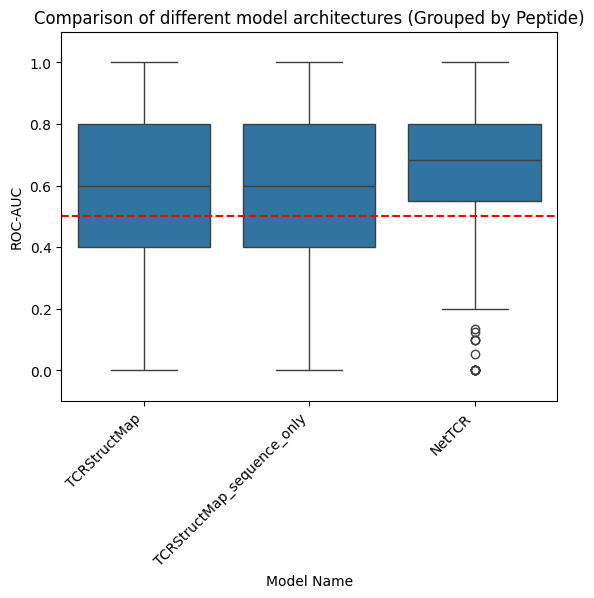

,mean,median,std
model_name,,,
TCRStructMap,0.594023,0.600000,0.259090
TCRStructMap_sequence_only,0.588137,0.600000,0.258198
NetTCR,0.670963,0.684353,0.226979


In [46]:
plt.title('Comparison of different model architectures (Grouped by Peptide)')

sns.boxplot(
    roc_results_by_peptide,
    x='model_name',
    y='roc_auc',
    order=sorted(roc_results_by_peptide['model_name'].unique(), key=model_name_sort_key),
)
plt.axhline(0.5, color='r', linestyle='dashed')

plt.ylabel('ROC-AUC')
plt.xlabel('Model Name')
plt.xticks(rotation=45, ha='right')
plt.ylim([-0.10, 1.1])
plt.show()

roc_results_by_peptide_agg = roc_results_by_peptide.groupby('model_name')['roc_auc'].agg(['mean', 'median', 'std'])
roc_results_by_peptide_agg = roc_results_by_peptide_agg.loc[
    sorted(roc_results_by_fold_agg.index, key=model_name_sort_key)
]

roc_results_by_peptide_agg

In [47]:
groups = list(roc_results_by_peptide.groupby('model_name')['roc_auc'])
groups = sorted(groups, key=lambda group: model_name_sort_key(group[0]))

print(stats.kruskal(*[group for _, group in groups]))

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.ranksums(group1, group2)

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

KruskalResult(statistic=np.float64(61.173398782230066), pvalue=np.float64(5.2043348889625714e-14))


,group1,group2,stat,p_val,signficant
0,TCRStructMap,TCRStructMap_sequence_only,0.570771,5.681550e-01,False
1,TCRStructMap,NetTCR,-6.430978,1.267853e-10,True
2,TCRStructMap_sequence_only,NetTCR,-7.032182,2.033277e-12,True


In [48]:
model_groups = roc_results_by_peptide.groupby('model_name')

fpr_interp = np.linspace(0, 1, 100)
tpr_interp = {}

for model_name, model_group in model_groups:
    tpr_interp[model_name] = {}
    for fold, fold_group in model_group.groupby('peptide'):
        group = fold_group.explode(['tpr', 'fpr'])

        tpr_interp[model_name][fold] = np.interp(fpr_interp, group['fpr'].apply(float), group['tpr'].apply(float))

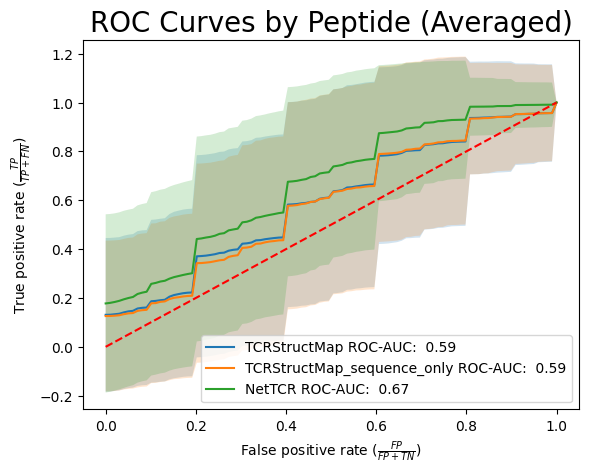

In [49]:
model_groups = roc_results_by_peptide.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=model_name_sort_key)

for model_name in model_group_names:
    model_group = model_groups.get_group(model_name)

    tpr_mean = np.mean(np.array(list(tpr_interp[model_name].values())).T, axis=1)
    tpr_std = np.std(np.array(list(tpr_interp[model_name].values())).T, axis=1)

    roc_auc = metrics.auc(fpr_interp, tpr_mean)

    plt.plot(fpr_interp, tpr_mean, label=f'{model_name} ROC-AUC: {roc_auc: .2f}')
    plt.fill_between(fpr_interp, tpr_mean - tpr_std, tpr_mean + tpr_std, alpha=0.2)

plt.title('ROC Curves by Peptide (Averaged)', fontsize=20)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel(r'False positive rate ($\frac{FP}{FP + TN}$)')
plt.ylabel(r'True positive rate ($\frac{TP}{TP + FN}$)')
plt.legend()

plt.show()

#### Comparison of prediction results to mimimum distance between the peptides and the training set

In [50]:
roc_results_by_peptide_by_peptide_distance = predictions.groupby(
    ['model_name', 'peptide', 'min_peptide_distance']
).apply(
    lambda group: metrics.roc_auc_score(group['label'], group['prediction']),
    include_groups=False,
)
roc_results_by_peptide_by_peptide_distance.name = 'roc_auc'

roc_results_by_peptide_by_peptide_distance = roc_results_by_peptide_by_peptide_distance.reset_index()

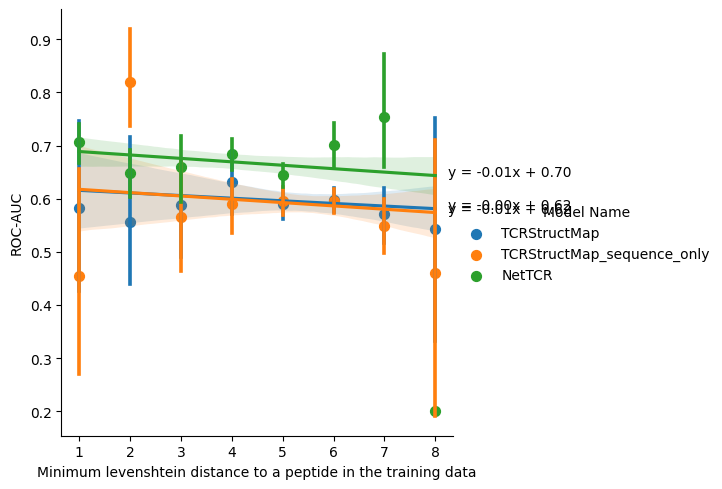

In [51]:
ax = sns.lmplot(
    roc_results_by_peptide_by_peptide_distance,
    x='min_peptide_distance',
    y='roc_auc',
    hue='model_name',
    hue_order=sorted(roc_results_by_peptide_by_peptide_distance['model_name'].unique(), key=model_name_sort_key),
    x_estimator=np.mean,
)

for model_name in roc_results_by_peptide_by_peptide_distance['model_name'].unique():
    subset = roc_results_by_peptide_by_peptide_distance[
        roc_results_by_peptide_by_peptide_distance['model_name'] == model_name
    ]
    slope, intercept, r_value, p_value, std_err = stats.linregress(subset['min_peptide_distance'], subset['roc_auc'])

    equation = f'y = {slope:.2f}x + {intercept:.2f}'

    x_pos = subset['min_peptide_distance'].max() + 0.25
    y_pos = slope * x_pos + intercept

    plt.text(x_pos, y_pos, equation, color='black')

ax.legend.set_title('Model Name')
plt.xlabel('Minimum levenshtein distance to a peptide in the training data')
plt.ylabel('ROC-AUC')

plt.show()

## Precision-Recall

In [52]:
pr_results = predictions.groupby(['model_name']).apply(
    lambda group: metrics.precision_recall_curve(group['label'], group['prediction']),
    include_groups=False,
)
pr_results.name = 'pr_curve'
pr_results = pr_results.reset_index()

In [53]:
pr_results[['precision', 'recall', 'threshold']] = pr_results['pr_curve'].apply(pd.Series)

In [54]:
pr_results['pr_auc'] = pr_results.apply(lambda row: metrics.auc(row['recall'], row['precision']), axis=1)

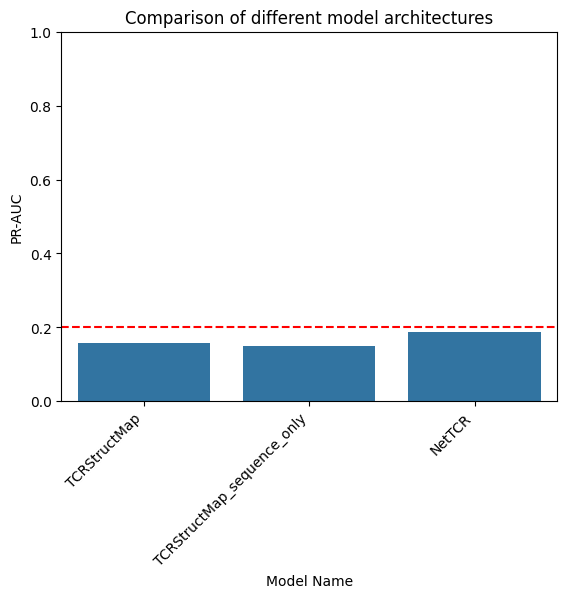

In [55]:
sns.barplot(pr_results, x='model_name', y='pr_auc', order=sorted(pr_results['model_name'], key=model_name_sort_key))
plt.axhline(1 / 5, color='r', linestyle='dashed')

plt.title('Comparison of different model architectures')
plt.ylim([0.0, 1.0])
plt.xlabel('Model Name')
plt.ylabel('PR-AUC')
plt.xticks(rotation=45, ha='right')
plt.show()

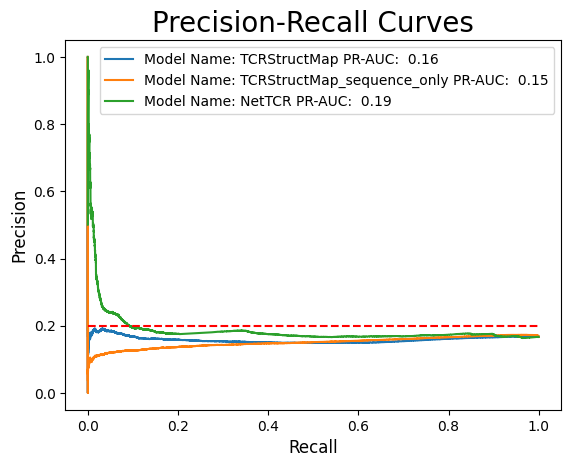

In [ ]:
model_groups = pr_results.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=lambda name: (-ord(name[0]), name, len(name)))

plt.title('Precision-Recall Curves', fontsize=20)

for model_name in model_group_names:
    model_group = model_groups.get_group(model_name)

    pr_auc = model_group['pr_auc'].to_numpy()[0]
    group = model_group.explode(['precision', 'recall'])

    plt.plot(group['recall'], group['precision'], label=f'Model Name: {model_name} PR-AUC: {pr_auc: .2f}')

plt.ylabel('Precision', fontsize=12)
plt.xlabel('Recall', fontsize=12)

plt.plot([0, 1], [1 / 5, 1 / 5], 'r--')
plt.legend()

plt.show()

### Grouping PR-AUC by Fold

In [57]:
pr_results_by_fold = predictions.groupby(['model_name', 'fold']).apply(
    lambda group: metrics.precision_recall_curve(group['label'], group['prediction']),
    include_groups=False,
)
pr_results_by_fold.name = 'pr_curve'
pr_results_by_fold = pr_results_by_fold.reset_index()

In [58]:
pr_results_by_fold[['precision', 'recall', 'threshold']] = pr_results_by_fold['pr_curve'].apply(pd.Series)

In [59]:
pr_results_by_fold['pr_auc'] = pr_results_by_fold.apply(
    lambda row: metrics.auc(row['recall'], row['precision']), axis=1
)

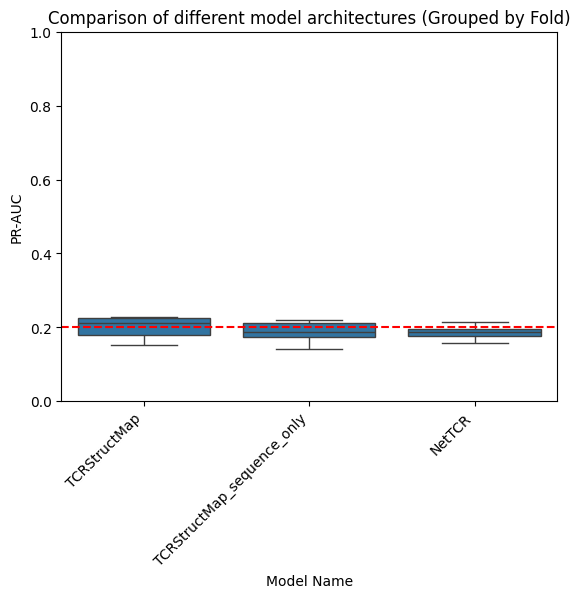

,mean,median,std
model_name,,,
TCRStructMap,0.199439,0.212683,0.033776
TCRStructMap_sequence_only,0.187274,0.187824,0.031545
NetTCR,0.186307,0.188025,0.021207


In [60]:
sns.boxplot(
    pr_results_by_fold,
    x='model_name',
    y='pr_auc',
    order=sorted(pr_results_by_fold['model_name'], key=model_name_sort_key),
)
plt.axhline(0.2, color='r', linestyle='dashed')

plt.title('Comparison of different model architectures (Grouped by Fold)')
plt.ylim([0.0, 1.0])
plt.xlabel('Model Name')
plt.ylabel('PR-AUC')
plt.xticks(rotation=45, ha='right')
plt.show()

pr_results_by_fold_agg = pr_results_by_fold.groupby('model_name')['pr_auc'].agg(['mean', 'median', 'std'])
pr_results_by_fold_agg = pr_results_by_fold_agg.loc[sorted(pr_results_by_fold_agg.index, key=model_name_sort_key)]
pr_results_by_fold_agg

In [61]:
groups = list(pr_results_by_fold.groupby('model_name')['pr_auc'])
groups = sorted(groups, key=lambda group: model_name_sort_key(group[0]))

print(stats.kruskal(*[group for _, group in groups]))

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.ranksums(group1, group2)

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

KruskalResult(statistic=np.float64(0.740000000000002), pvalue=np.float64(0.6907343306373539))


,group1,group2,stat,p_val,signficant
0,TCRStructMap,TCRStructMap_sequence_only,0.731126,0.464702,False
1,TCRStructMap,NetTCR,0.731126,0.464702,False
2,TCRStructMap_sequence_only,NetTCR,-0.104447,0.916815,False


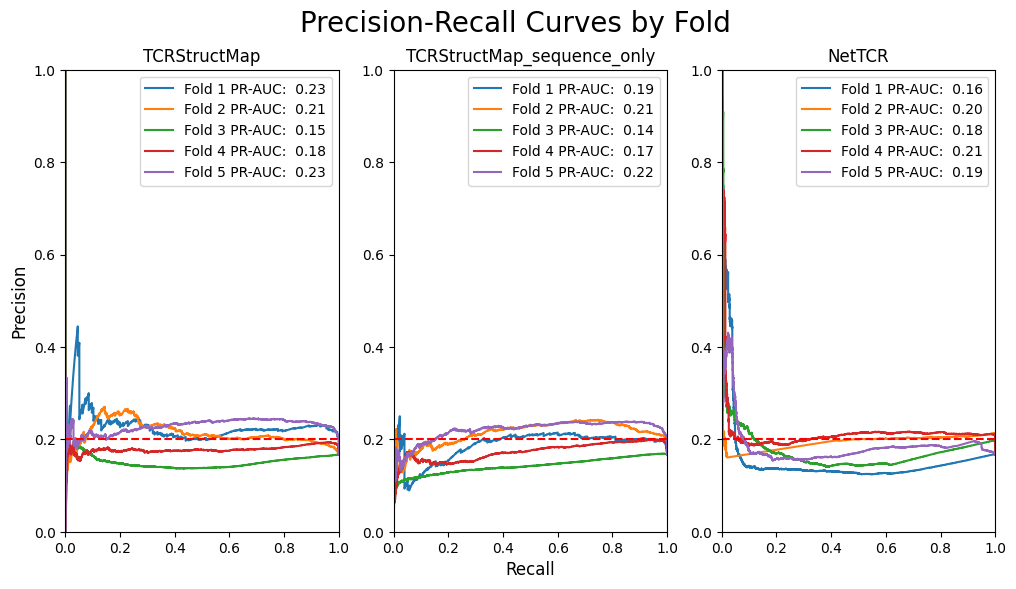

In [62]:
model_groups = pr_results_by_fold.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=model_name_sort_key)

fig, axes = plt.subplots(1, len(model_groups), figsize=(12, 6))

fig.suptitle('Precision-Recall Curves by Fold', fontsize=20)

for i, model_name in enumerate(model_group_names):
    model_group = model_groups.get_group(model_name)

    for fold, fold_group in model_group.groupby('fold'):
        pr_auc = fold_group['pr_auc'].to_numpy()[0]
        group = fold_group.explode(['recall', 'precision'])

        axes[i].plot(group['recall'], group['precision'], label=f'Fold {fold} PR-AUC: {pr_auc: .2f}')

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [1 / 5, 1 / 5], 'r--')

    if i == 0:
        axes[i].set_ylabel('Precision', fontsize=12)

    if i == len(model_groups) // 2:
        axes[i].set_xlabel('Recall', fontsize=12)

    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0, 1])
    axes[i].legend()

In [63]:
model_groups = pr_results_by_fold.groupby('model_name')

recall_interp = np.linspace(0, 1, 100)
precision_interp = {}

for model_name, model_group in model_groups:
    precision_interp[model_name] = {}
    for fold, fold_group in model_group.groupby('fold'):
        group = fold_group.explode(['recall', 'precision'])

        precision_interp[model_name][fold] = np.interp(
            recall_interp,
            group['recall'].apply(float)[::-1],
            group['precision'].apply(float)[::-1],
        )

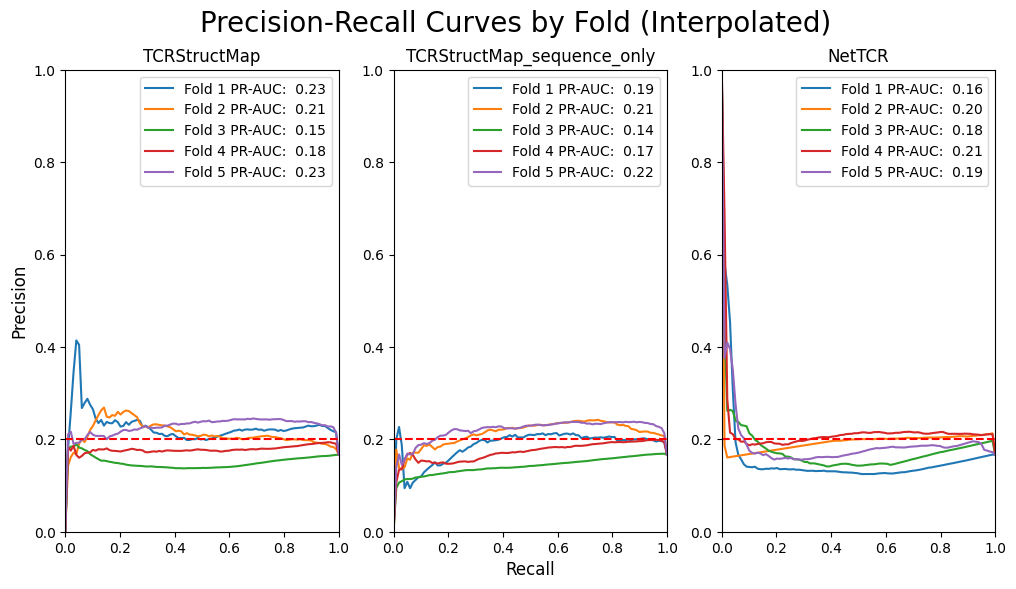

In [64]:
model_groups = pr_results_by_fold.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=model_name_sort_key)

fig, axes = plt.subplots(1, len(model_groups), figsize=(12, 6))

fig.suptitle('Precision-Recall Curves by Fold (Interpolated)', fontsize=20)

for i, model_name in enumerate(model_group_names):
    model_group = model_groups.get_group(model_name)

    for fold, fold_group in model_group.groupby('fold'):
        pr_auc = fold_group['pr_auc'].to_numpy()[0]

        axes[i].plot(recall_interp, precision_interp[model_name][fold], label=f'Fold {fold} PR-AUC: {pr_auc: .2f}')

    if i == 0:
        axes[i].set_ylabel('Precision', fontsize=12)

    if i == len(model_groups) // 2:
        axes[i].set_xlabel('Recall', fontsize=12)

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [1 / 5, 1 / 5], 'r--')
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0, 1])
    axes[i].legend()

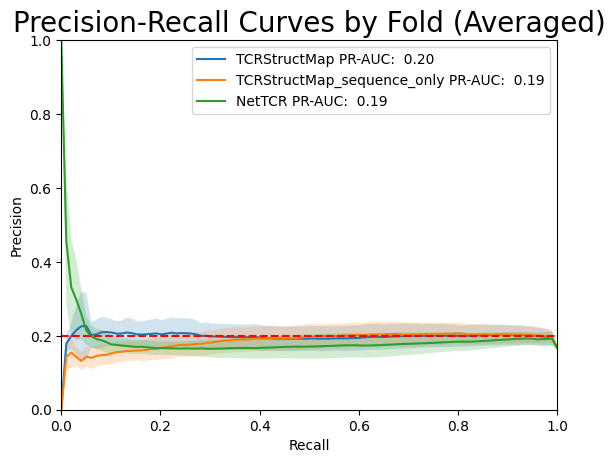

In [65]:
model_groups = pr_results_by_fold.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=model_name_sort_key)

for model_name in model_group_names:
    precision_mean = np.mean(np.array(list(precision_interp[model_name].values())).T, axis=1)
    precision_std = np.std(np.array(list(precision_interp[model_name].values())).T, axis=1)

    pr_auc = metrics.auc(recall_interp, precision_mean)

    plt.plot(recall_interp, precision_mean, label=f'{model_name} PR-AUC: {pr_auc: .2f}')
    plt.fill_between(recall_interp, precision_mean - precision_std, precision_mean + precision_std, alpha=0.2)

plt.title('Precision-Recall Curves by Fold (Averaged)', fontsize=20)
plt.plot([0, 1], [1 / 5, 1 / 5], 'r--')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.legend()

plt.show()

### Balancing classes

In [66]:
def down_sample_group(group: pd.DataFrame, random_state: int | np.random.Generator | None = None) -> pd.DataFrame:
    positives = group[group['label'] == 1]
    negatives = group[group['label'] == 0]

    num_positives = len(positives)
    num_negatives = len(negatives)

    if num_positives > num_negatives:
        return pd.concat([positives.sample(num_negatives, random_state=random_state), negatives])

    if num_positives < num_negatives:
        return pd.concat([positives, negatives.sample(num_positives, random_state=random_state)])

    return group


rng = np.random.default_rng(123)
balanced_predictions = (
    predictions.groupby(['model_name', 'fold'])
    .apply(
        down_sample_group,
        random_state=rng,
        include_groups=False,
    )
    .reset_index()
)

In [67]:
pr_results_by_fold_balanced = balanced_predictions.groupby(['model_name', 'fold']).apply(
    lambda group: metrics.precision_recall_curve(group['label'], group['prediction']),
    include_groups=False,
)
pr_results_by_fold_balanced.name = 'pr_curve'
pr_results_by_fold_balanced = pr_results_by_fold_balanced.reset_index()

In [68]:
pr_results_by_fold_balanced[['precision', 'recall', 'threshold']] = pr_results_by_fold_balanced['pr_curve'].apply(
    pd.Series
)

In [69]:
pr_results_by_fold_balanced['pr_auc'] = pr_results_by_fold_balanced.apply(
    lambda row: metrics.auc(row['recall'], row['precision']), axis=1
)

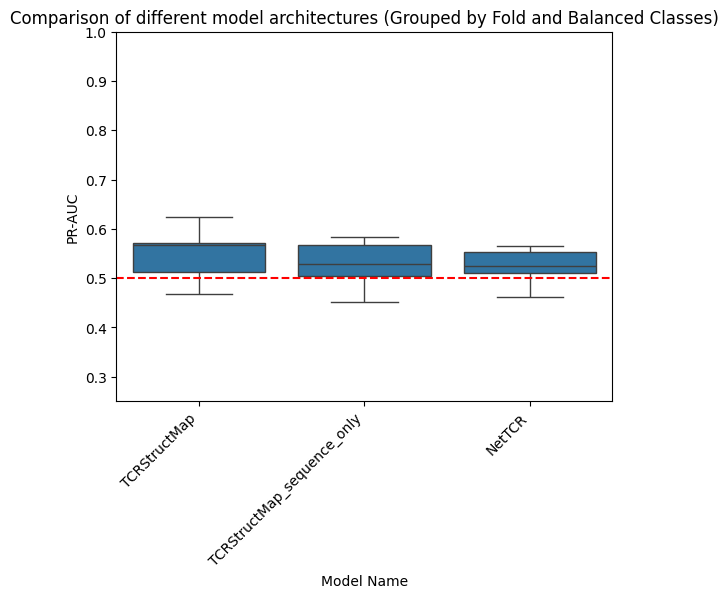

,mean,median,std
model_name,,,
TCRStructMap,0.548977,0.568117,0.060079
TCRStructMap_sequence_only,0.526868,0.528406,0.052356
NetTCR,0.522847,0.523813,0.040699


In [70]:
sns.boxplot(
    pr_results_by_fold_balanced,
    x='model_name',
    y='pr_auc',
    order=sorted(pr_results_by_fold_balanced['model_name'].unique(), key=model_name_sort_key),
)
plt.axhline(0.5, color='r', linestyle='dashed')

plt.title('Comparison of different model architectures (Grouped by Fold and Balanced Classes)')
plt.xlabel('Model Name')
plt.ylabel('PR-AUC')
plt.xticks(rotation=45, ha='right')
plt.ylim([0.25, 1.0])
plt.show()

pr_results_by_fold_balanced_agg = pr_results_by_fold_balanced.groupby('model_name')['pr_auc'].agg(
    ['mean', 'median', 'std']
)
pr_results_by_fold_balanced_agg = pr_results_by_fold_balanced_agg.loc[
    sorted(pr_results_by_fold_balanced_agg.index, key=model_name_sort_key)
]
pr_results_by_fold_balanced_agg

In [71]:
groups = list(pr_results_by_fold_balanced.groupby('model_name')['pr_auc'])
groups = sorted(groups, key=lambda group: model_name_sort_key(group[0]))

print(stats.kruskal(*[group for _, group in groups]))

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.ranksums(group1, group2)

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

KruskalResult(statistic=np.float64(1.3400000000000034), pvalue=np.float64(0.5117085777865417))


,group1,group2,stat,p_val,signficant
0,TCRStructMap,TCRStructMap_sequence_only,0.731126,0.464702,False
1,TCRStructMap,NetTCR,1.148913,0.250592,False
2,TCRStructMap_sequence_only,NetTCR,0.313340,0.754023,False


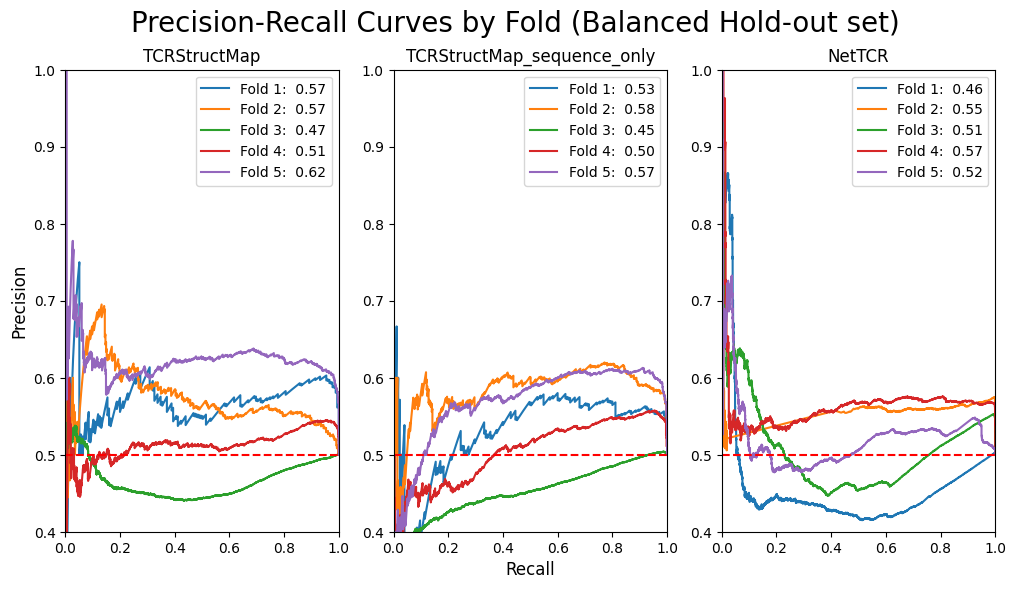

In [72]:
model_groups = pr_results_by_fold_balanced.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=model_name_sort_key)

fig, axes = plt.subplots(1, len(model_groups), figsize=(12, 6))

fig.suptitle('Precision-Recall Curves by Fold (Balanced Hold-out set)', fontsize=20)

for i, model_name in enumerate(model_group_names):
    model_group = model_groups.get_group(model_name)

    for fold, fold_group in model_group.groupby('fold'):
        roc_auc = fold_group['pr_auc'].to_numpy()[0]
        group = fold_group.explode(['recall', 'precision'])

        axes[i].plot(group['recall'], group['precision'], label=f'Fold {fold}: {roc_auc: .2f}')

    if i == 0:
        axes[i].set_ylabel('Precision', fontsize=12)

    if i == len(model_groups) // 2:
        axes[i].set_xlabel('Recall', fontsize=12)

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [0.5, 0.5], 'r--')
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0.4, 1])
    axes[i].legend()

In [73]:
model_groups = pr_results_by_fold_balanced.groupby('model_name')

recall_interp = np.linspace(0, 1, 100)
precision_interp = {}

for model_name, model_group in model_groups:
    precision_interp[model_name] = {}
    for fold, fold_group in model_group.groupby('fold'):
        group = fold_group.explode(['recall', 'precision'])

        precision_interp[model_name][fold] = np.interp(
            recall_interp,
            group['recall'].apply(float)[::-1],
            group['precision'].apply(float)[::-1],
        )

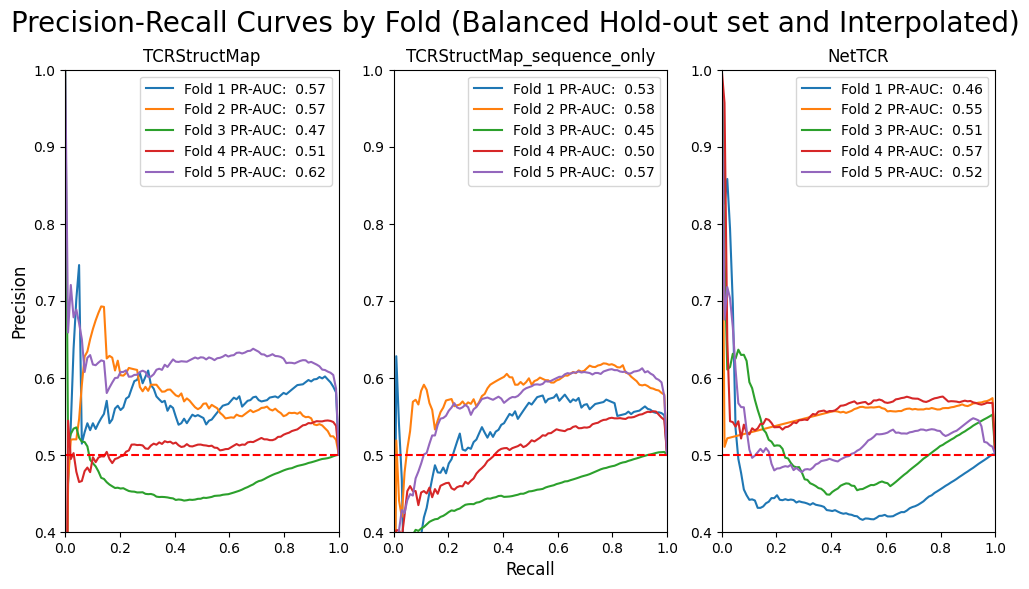

In [74]:
model_groups = pr_results_by_fold_balanced.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=model_name_sort_key)

fig, axes = plt.subplots(1, len(model_groups), figsize=(12, 6))

fig.suptitle('Precision-Recall Curves by Fold (Balanced Hold-out set and Interpolated)', fontsize=20)

for i, model_name in enumerate(model_group_names):
    model_group = model_groups.get_group(model_name)

    for fold, fold_group in model_group.groupby('fold'):
        pr_auc = fold_group['pr_auc'].to_numpy()[0]

        axes[i].plot(recall_interp, precision_interp[model_name][fold], label=f'Fold {fold} PR-AUC: {pr_auc: .2f}')

    if i == 0:
        axes[i].set_ylabel('Precision', fontsize=12)

    if i == len(model_groups) // 2:
        axes[i].set_xlabel('Recall', fontsize=12)

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [0.5, 0.5], 'r--')
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0.4, 1])
    axes[i].legend()

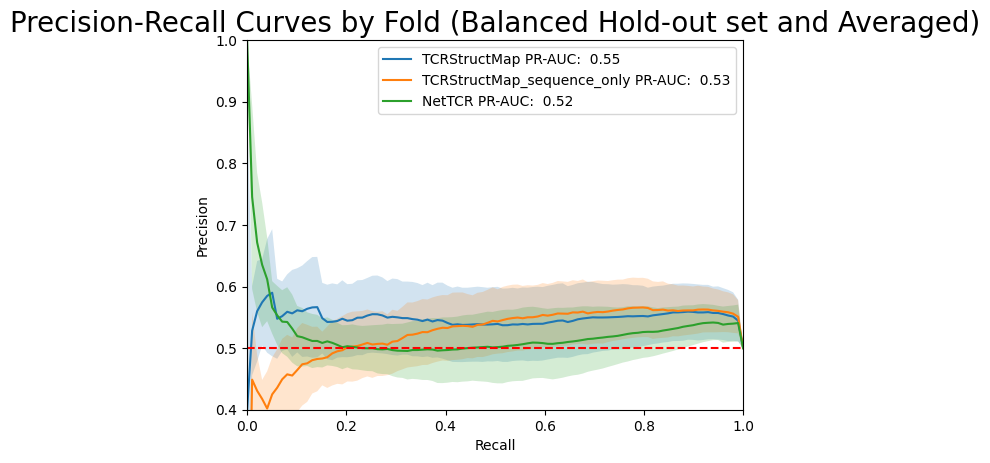

In [75]:
model_groups = pr_results_by_fold_balanced.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=model_name_sort_key)

for model_name in model_group_names:
    precision_mean = np.mean(np.array(list(precision_interp[model_name].values())).T, axis=1)
    precision_std = np.std(np.array(list(precision_interp[model_name].values())).T, axis=1)

    pr_auc = metrics.auc(recall_interp, precision_mean)

    plt.plot(recall_interp, precision_mean, label=f'{model_name} PR-AUC: {pr_auc: .2f}')
    plt.fill_between(recall_interp, precision_mean - precision_std, precision_mean + precision_std, alpha=0.2)

plt.title('Precision-Recall Curves by Fold (Balanced Hold-out set and Averaged)', fontsize=20)
plt.plot([0, 1], [0.5, 0.5], 'r--')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.xlim([0, 1])
plt.ylim([0.4, 1])
plt.legend()

plt.show()

## F1-Score

In [76]:
THRESHOLD = 0.5
predictions['prediction_binary'] = (predictions['prediction'] > THRESHOLD).apply(int)

In [77]:
f1_results = predictions.groupby(['model_name']).apply(
    lambda row: metrics.f1_score(row['label'], row['prediction_binary']),
    include_groups=False,
)
f1_results.name = 'f1_score'
f1_results = f1_results.reset_index()

f1_results.set_index('model_name').loc[sorted(f1_results['model_name'], key=model_name_sort_key)]

,f1_score
model_name,
TCRStructMap,0.132935
TCRStructMap_sequence_only,0.102906
NetTCR,0.017340


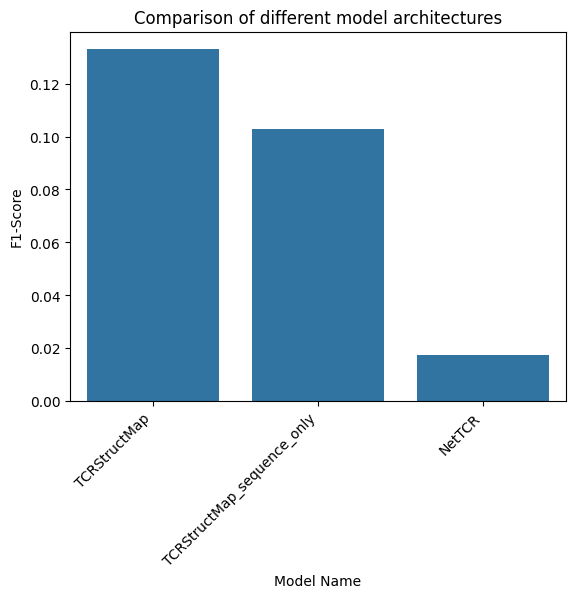

In [78]:
sns.barplot(
    f1_results,
    x='model_name',
    y='f1_score',
    order=sorted(f1_results['model_name'].unique(), key=model_name_sort_key),
)

plt.title('Comparison of different model architectures')
plt.xlabel('Model Name')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')
plt.show()

### Grouping F1-Score by Fold

In [79]:
f1_results_by_fold = predictions.groupby(['model_name', 'fold']).apply(
    lambda row: metrics.f1_score(row['label'], row['prediction_binary']),
    include_groups=False,
)
f1_results_by_fold.name = 'f1_score'
f1_results_by_fold = f1_results_by_fold.reset_index()

f1_results_table = f1_results_by_fold.pivot_table(index='fold', columns='model_name', values='f1_score')
f1_results_table = f1_results_table[sorted(f1_results_table.columns, key=model_name_sort_key)]
f1_results_table

model_name,TCRStructMap,TCRStructMap_sequence_only,NetTCR
fold,,,
1,0.166667,0.072464,0.035861
2,0.190337,0.162025,0.000000
3,0.132298,0.098994,0.014324
4,0.097100,0.098013,0.015288
5,0.147583,0.141447,0.015544


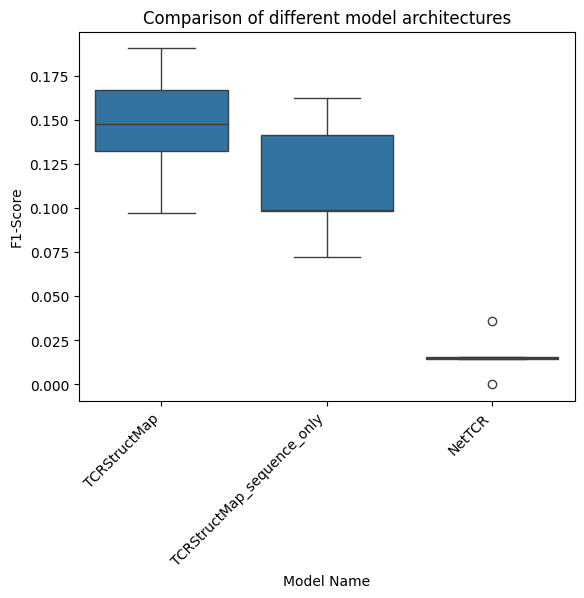

,mean,median,std
model_name,,,
TCRStructMap,0.146797,0.147583,0.035253
TCRStructMap_sequence_only,0.114589,0.098994,0.036277
NetTCR,0.016203,0.015288,0.012785


In [80]:
sns.boxplot(
    f1_results_by_fold,
    x='model_name',
    y='f1_score',
    order=sorted(f1_results_by_fold['model_name'].unique(), key=model_name_sort_key),
)

plt.title('Comparison of different model architectures')
plt.xlabel('Model Name')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')
plt.show()

f1_results_by_fold_agg = f1_results_by_fold.groupby('model_name')['f1_score'].agg(['mean', 'median', 'std'])
f1_results_by_fold_agg = f1_results_by_fold_agg.loc[sorted(f1_results_by_fold_agg.index, key=model_name_sort_key)]
f1_results_by_fold_agg

In [81]:
groups = list(f1_results_by_fold.groupby('model_name')['f1_score'])
groups = sorted(groups, key=lambda group: model_name_sort_key(group[0]))

print(stats.kruskal(*[group for _, group in groups]))

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.ranksums(group1, group2)

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

KruskalResult(statistic=np.float64(9.979999999999997), pvalue=np.float64(0.006805664492230557))


,group1,group2,stat,p_val,signficant
0,TCRStructMap,TCRStructMap_sequence_only,1.148913,0.250592,False
1,TCRStructMap,NetTCR,2.611165,0.009023,True
2,TCRStructMap_sequence_only,NetTCR,2.611165,0.009023,True


### Balancing classes

In [82]:
balanced_predictions['prediction_binary'] = (balanced_predictions['prediction'] > THRESHOLD).apply(int)

In [83]:
f1_results_by_fold_balanced = balanced_predictions.groupby(['model_name', 'fold']).apply(
    lambda row: metrics.f1_score(row['label'], row['prediction_binary']),
    include_groups=False,
)
f1_results_by_fold_balanced.name = 'f1_score'
f1_results_by_fold_balanced = f1_results_by_fold_balanced.reset_index()

f1_results_balanced_table = f1_results_by_fold_balanced.pivot_table(
    index='fold', columns='model_name', values='f1_score'
)
f1_results_balanced_table = f1_results_balanced_table[
    sorted(f1_results_balanced_table.columns, key=model_name_sort_key)
]
f1_results_balanced_table

model_name,TCRStructMap,TCRStructMap_sequence_only,NetTCR
fold,,,
1,0.211982,0.098039,0.036256
2,0.244361,0.233577,0.000000
3,0.183882,0.140762,0.014362
4,0.118616,0.120423,0.015329
5,0.192053,0.183369,0.015693


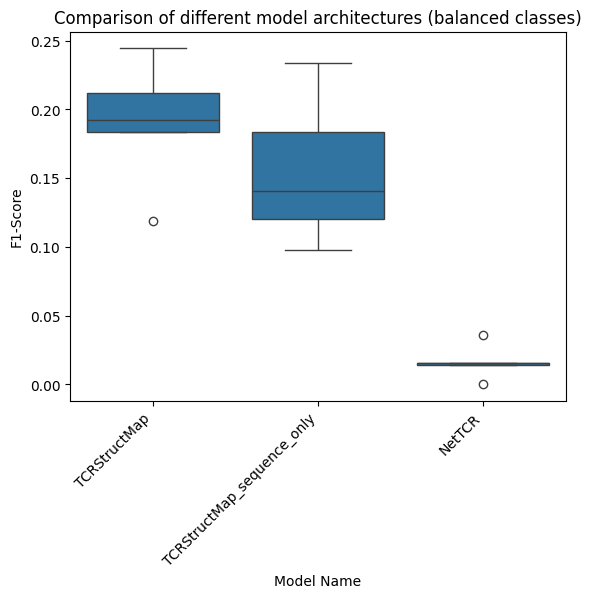

,mean,median,std
model_name,,,
TCRStructMap,0.190179,0.192053,0.046302
TCRStructMap_sequence_only,0.155234,0.140762,0.053902
NetTCR,0.016328,0.015329,0.012932


In [84]:
sns.boxplot(
    f1_results_by_fold_balanced,
    x='model_name',
    y='f1_score',
    order=sorted(f1_results_by_fold_balanced['model_name'].unique(), key=model_name_sort_key),
)

plt.title('Comparison of different model architectures (balanced classes)')
plt.xlabel('Model Name')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')
plt.show()

f1_results_by_fold_balanced_agg = f1_results_by_fold_balanced.groupby('model_name')['f1_score'].agg(
    ['mean', 'median', 'std']
)
f1_results_by_fold_balanced_agg = f1_results_by_fold_balanced_agg.loc[
    sorted(f1_results_by_fold_balanced_agg.index, key=model_name_sort_key)
]
f1_results_by_fold_balanced_agg

In [85]:
groups = list(f1_results_by_fold_balanced.groupby('model_name')['f1_score'])
groups = sorted(groups, key=lambda group: model_name_sort_key(group[0]))

print(stats.kruskal(*[group for _, group in groups]))

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.ranksums(group1, group2)

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

KruskalResult(statistic=np.float64(9.979999999999997), pvalue=np.float64(0.006805664492230557))


,group1,group2,stat,p_val,signficant
0,TCRStructMap,TCRStructMap_sequence_only,1.148913,0.250592,False
1,TCRStructMap,NetTCR,2.611165,0.009023,True
2,TCRStructMap_sequence_only,NetTCR,2.611165,0.009023,True
